#### Exercise 1 Property Rental Assistant
A property management agent needs to help potential tenants by checking listing availability and calculating the total "Move-In Cost" (security deposit + first month's rent).

Problem Statement
    
    Step 1: The user asks about a specific property (e.g., "Apartment 4B").
    
    Step 2: The agent must first check if the unit is available in the database.
    
    Step 3: If available, the agent must calculate the total cost based on the rent price and the state's tax/deposit requirements. If not ask user to provide proper property name
    
    Step 4: The agent provides a final summary to the user.

In [15]:
from langchain.tools import tool

In [23]:

from typing import Literal, Annotated
from langgraph.graph import END, START
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import add_messages
import json

In [32]:
import os


# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0",cohere.command-r-plus-v1:0 region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id= "amazon.nova-lite-v1:0", #"anthropic.claude-3-sonnet-20240229-v1:0",          #"", 
                          region_name="us-east-1",
                          temperature=0.5, 
                          max_tokens=1000)

llm.invoke('hi').content

"Hello! How can I assist you today? If you have any questions or need information on a particular topic, feel free to ask. Whether it's about science, technology, history, or something else, I'm here to help. If you're looking for recommendations or advice, just let me know what you're interested in!"

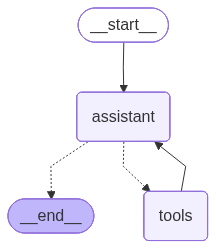

In [33]:
# --- 1. Define Tools (Standard Python Functions) ---

@tool
def check_property_status(unit_id: str):
    """Checks if a rental unit is currently available or occupied."""
    # Simulation of a database lookup
    database = {"4B": {"status": "Available", "rent": 2500}, "12A": {"status": "Occupied", "rent": 3000}}
    return database.get(unit_id, "Unit not found")

@tool
def calculate_move_in_costs(monthly_rent: float, pet_deposit: bool = False):
    """Calculates total cost: 1 month rent + 1 month security deposit + optional $500 pet fee."""
    total = (monthly_rent * 2) + (500 if pet_deposit else 0)
    return f"Total move-in cost is ${total} (Rent + Security + Fees)."

# --- 2. Build the Graph ---

# List of tools available for the ToolNode
tools = [check_property_status, calculate_move_in_costs]
# Bind tools so the LLM knows how to call them
llm_with_tools = llm.bind_tools(tools)

builder = StateGraph(Annotated[list, add_messages])

# Assistant node to process user intent
builder.add_node("assistant", lambda state: llm_with_tools.invoke(state))
# ToolNode to execute the actual functions
builder.add_node("tools", ToolNode(tools))

# --- 3. Define Flow Logic ---

# Always start with the assistant
builder.add_edge(START, "assistant")
# Check if the assistant wants to call a tool or end the chat
builder.add_conditional_edges("assistant", tools_condition)
# Return to assistant after tools finish to provide the final answer
builder.add_edge("tools", "assistant")

graph = builder.compile()
builder.compile()



In [34]:
# --- Execution Flow ---
# The LLM will call 'check_property_status' first, get the rent, then call 'calculate_move_in_costs'

from rich import print
inputs = [("user", "Is Apartment 4B available? If so, what is the move-in cost? I have a cat.")]
for msg in graph.stream(inputs):
    print(msg)

{
    'assistant': AIMessage(
        content=[
            {
                'type': 'text',
                'text': '<thinking>The User wants to know if Apartment 4B is available and the move-in cost if it 
is. I need to first check the status of the apartment and then calculate the move-in cost. I will start by checking
the status of Apartment 4B.</thinking>\n'
            },
            {
                'type': 'tool_use',
                'name': 'check_property_status',
                'input': {'unit_id': '4B'},
                'id': 'tooluse_GvJxHpT9vSnUnRwXKulD32'
            }
        ],
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': '4739eee3-34c8-4c3a-8c13-d4bb56a7dc8d',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Tue, 10 Mar 2026 15:47:11 GMT',
                    'content-type': 'application/json',
                    'content-length': '564',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': '4739eee3-34c8-4c3a-8c13-d4bb56a7dc8d'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'tool_use',
            'metrics': {'latencyMs': [822]},
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='run--a3ae87f2-7ae0-4e7a-a762-fd1a0982ba1f-0',
        tool_calls=[
            {
                'name': 'check_property_status',
                'args': {'unit_id': '4B'},
                'id': 'tooluse_GvJxHpT9vSnUnRwXKulD32',
                'type': 'tool_call'
            }
        ],
        usage_metadata={
            'input_tokens': 505,
            'output_tokens': 80,
            'total_tokens': 585,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    )
}

{
    'tools': [
        ToolMessage(
            content='{"status": "Available", "rent": 2500}',
            name='check_property_status',
            id='9f7ce94d-6113-4f34-844c-087b54304898',
            tool_call_id='tooluse_GvJxHpT9vSnUnRwXKulD32'
        )
    ]
}

{
    'assistant': AIMessage(
        content=[
            {
                'type': 'text',
                'text': '<thinking>Apartment 4B is available, and the monthly rent is $2500. Since the User has a 
cat, I need to include a pet fee in the move-in cost calculation. I will now calculate the move-in cost.</thinking>
'
            },
            {
                'type': 'tool_use',
                'name': 'calculate_move_in_costs',
                'input': {'monthly_rent': 2500, 'pet_deposit': True},
                'id': 'tooluse_hN3W6dExB1gkZkXWMlNHHx'
            }
        ],
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': 'e015de46-1ffd-4deb-9b3b-22ba38b9b87a',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Tue, 10 Mar 2026 15:47:12 GMT',
                    'content-type': 'application/json',
                    'content-length': '550',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': 'e015de46-1ffd-4deb-9b3b-22ba38b9b87a'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'tool_use',
            'metrics': {'latencyMs': [839]},
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='run--30894394-8bf1-49ec-b18f-c445a1b56bd2-0',
        tool_calls=[
            {
                'name': 'calculate_move_in_costs',
                'args': {'monthly_rent': 2500, 'pet_deposit': True},
                'id': 'tooluse_hN3W6dExB1gkZkXWMlNHHx',
                'type': 'tool_call'
            }
        ],
        usage_metadata={
            'input_tokens': 627,
            'output_tokens': 88,
            'total_tokens': 715,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    )
}

{
    'tools': [
        ToolMessage(
            content='Total move-in cost is $5500.0 (Rent + Security + Fees).',
            name='calculate_move_in_costs',
            id='ddf95c08-367c-4b67-815a-3a72eaceb271',
            tool_call_id='tooluse_hN3W6dExB1gkZkXWMlNHHx'
        )
    ]
}

{
    'assistant': AIMessage(
        content="<thinking>I have successfully calculated the move-in cost for Apartment 4B, which includes the 
monthly rent, a security deposit equal to one month's rent, and a $500 pet fee. I can now provide the User with the
move-in cost.</thinking>\n\nApartment 4B is available, and the total move-in cost, including the monthly rent, a 
security deposit equal to one month's rent, and a $500 pet fee, is $5500.0.",
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': 'fd3bb05a-995d-48c1-82b9-ff4195348df2',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Tue, 10 Mar 2026 15:47:14 GMT',
                    'content-type': 'application/json',
                    'content-length': '605',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': 'fd3bb05a-995d-48c1-82b9-ff4195348df2'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'end_turn',
            'metrics': {'latencyMs': [1401]},
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='run--ef0bca89-abb0-4cbc-880a-db86d3eef641-0',
        usage_metadata={
            'input_tokens': 766,
            'output_tokens': 108,
            'total_tokens': 874,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    )
}

In [35]:
from rich import print
inputs = [("user", "Is Apartment 44B available? If so, what is the move-in cost? I have a cat.")]
for msg in graph.stream(inputs):
    print(msg)

{
    'assistant': AIMessage(
        content=[
            {
                'type': 'text',
                'text': "<thinking>I need to first check if Apartment 44B is available. If it is, I'll then 
calculate the move-in cost, which includes a pet fee since the user has a cat.</thinking>\n"
            },
            {
                'type': 'tool_use',
                'name': 'check_property_status',
                'input': {'unit_id': '44B'},
                'id': 'tooluse_HFrd9lNJm1oi4wX0QfOrUR'
            }
        ],
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': 'bce6ed79-7adc-47e4-aab4-2e50871b5429',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Tue, 10 Mar 2026 15:47:15 GMT',
                    'content-type': 'application/json',
                    'content-length': '494',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': 'bce6ed79-7adc-47e4-aab4-2e50871b5429'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'tool_use',
            'metrics': {'latencyMs': [740]},
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='run--8becbfb6-73c7-42eb-a3b8-4e4fbac3e0a4-0',
        tool_calls=[
            {
                'name': 'check_property_status',
                'args': {'unit_id': '44B'},
                'id': 'tooluse_HFrd9lNJm1oi4wX0QfOrUR',
                'type': 'tool_call'
            }
        ],
        usage_metadata={
            'input_tokens': 506,
            'output_tokens': 68,
            'total_tokens': 574,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    )
}

{
    'tools': [
        ToolMessage(
            content='Unit not found',
            name='check_property_status',
            id='f798b104-4402-45d6-be19-760d36a11e3c',
            tool_call_id='tooluse_HFrd9lNJm1oi4wX0QfOrUR'
        )
    ]
}

{
    'assistant': AIMessage(
        content="<thinking>The tool indicates that the unit was not found, which could mean there is an issue with 
the unit ID. I'll ask the user to confirm the unit ID to ensure accuracy.</thinking>\n\nHi there, it seems there 
might be an issue with the unit ID. Could you please confirm the unit ID for Apartment 44B? This will help me 
accurately check the availability and calculate the move-in cost.",
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': '993b81be-d6a0-460a-aaad-4b1f709b4a6b',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Tue, 10 Mar 2026 15:47:16 GMT',
                    'content-type': 'application/json',
                    'content-length': '590',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': '993b81be-d6a0-460a-aaad-4b1f709b4a6b'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'end_turn',
            'metrics': {'latencyMs': [830]},
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='run--2ff63cbd-3320-41f1-ba01-ba5c6a7e146e-0',
        usage_metadata={
            'input_tokens': 606,
            'output_tokens': 87,
            'total_tokens': 693,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    )
}

## Exercise 2: The Healthcare Appointment Guard

**Use Case:** A medical scheduling agent that handles **New Patient Intake** and **Appointment Booking**. It must prevent cross-field logic errors (e.g., booking an adult in the Pediatrics wing).

### Problem Statement

The agent uses a `BookAppointment` tool.

1. **Age Check:** The patient age must be between 0 and 120.
2. **Department Logic:** If the department is set to "Pediatrics," the patient's age must be under 18.
If a user says "I am 35 and need to see a doctor in Pediatrics," the validation should fail with a specific message: *"Error: Pediatrics is only for patients under 18."* The model must then suggest "General Medicine" to the user.

### Logic Steps to Solve

1. **Define the Schema:** Create a `BookAppointment` Pydantic model.
2. **Add Root Validation:** Use Pydantic's `@model_validator(mode="after")` to compare the `age` and `department` fields together.
3. **Graph Setup:** * **Node `model**`: Receives the user request.
* **Node `validation**`: Intercepts the `BookAppointment` call.


4. **The Reprompt Logic:**
* When the age/department conflict occurs, the `ValidationNode` passes the `ValueError` back to the model.
* The `should_reprompt` function detects the error.
* The **LLM** sees the error message and generates a natural language clarification to the user ("I'm sorry, I can't book you in Pediatrics because you are 35...").


In [3]:
from pydantic import BaseModel, Field, model_validator
from typing import Literal, Annotated
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ValidationNode
from langgraph.graph.message import add_messages
import json

In [5]:
import os


# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0",cohere.command-r-plus-v1:0 region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id= "anthropic.claude-3-sonnet-20240229-v1:0",          #"amazon.nova-lite-v1:0", 
                          region_name="us-east-1",
                          temperature=0.5, 
                          max_tokens=1000)

llm.invoke('hi').content

'Hello!'

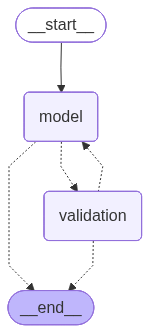

In [11]:

# 1. Define the Schema with Cross-Field Validation
class BookAppointment(BaseModel):
    patient_name: str
    patient_age: int = Field(..., description="Age of the patient in years")
    department: Literal["Pediatrics", "General Medicine", "Cardiology"]
    date: str

    @model_validator(mode="after")
    def validate_department_age(self) -> "BookAppointment":
        # Cross-field logic: Pediatrics is age-restricted
        if self.department == "Pediatrics" and self.patient_age >= 18:
            raise ValueError(
                f"Validation Error: {self.patient_name} is {self.patient_age} years old. "
                "Pediatrics is strictly for patients under 18. Please choose General Medicine."
            )
        return self

# 2. Setup Nodes and Graph
builder = StateGraph(Annotated[list, add_messages])

# Bind the booking tool to your Bedrock LLM
llm_with_booking = llm.bind_tools([BookAppointment])

builder.add_node("model", lambda state: llm_with_booking.invoke(state))
builder.add_node("validation", ValidationNode([BookAppointment]))

# 3. Define Logic Flow
builder.add_edge(START, "model")

def should_validate(state: list) -> Literal["validation", "__end__"]:
    if state[-1].tool_calls:
        return "validation"
    return END

def should_reprompt(state: list) -> Literal["model", "__end__"]:
    # Check the last tool message for the 'is_error' flag
    for msg in reversed(state):
        if msg.type == "tool":
            if msg.additional_kwargs.get("is_error"):
                return "model" # Loop back to LLM to fix the error
            break
    return END

builder.add_conditional_edges("model", should_validate)
builder.add_conditional_edges("validation", should_reprompt)

graph = builder.compile()

builder.compile()

In [12]:
# An adult trying to book Pediatrics
inputs = [("user", "I am 12 years old and I want to book an appointment in Pediatrics for tomorrow.")]
res = graph.invoke(inputs)

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I am 12 years old and I want to book an appointment in Pediatrics for tomorrow.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Okay, let's book an appointment in the Pediatrics department for you tomorrow. Here's how we can invoke the BookAppointment tool:"}, {'type': 'tool_use', 'name': 'BookAppointment', 'input': {'patient_name': 'Your Name', 'patient_age': 12, 'department': 'Pediatrics', 'date': "Tomorrow's Date"}, 'id': 'tooluse_rPDbxReSoEUYYWtriH8xYQ'}]
Tool Calls:
  BookAppointment (tooluse_rPDbxReSoEUYYWtriH8xYQ)
 Call ID: tooluse_rPDbxReSoEUYYWtriH8xYQ
  Args:
    patient_name: Your Name
    patient_age: 12
    department: Pediatrics
    date: Tomorrow's Date
================================= Tool Message =================================
Name: BookAppointment

{"patient_name":"Your Name","patient_age":12,"department":"Pediatrics","date

In [13]:
# An adult trying to book Pediatrics
inputs = [("user", "I am 32 years old and I want to book an appointment in Pediatrics for tomorrow.")]
res = graph.invoke(inputs)

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I am 32 years old and I want to book an appointment in Pediatrics for tomorrow.
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'm afraid I cannot book an appointment for you in the Pediatrics department since that is intended for children. At 32 years old, you would need to book an appointment in either the General Medicine or Cardiology department instead. Here is how we can book your appointment:"}, {'type': 'tool_use', 'name': 'BookAppointment', 'input': {'patient_name': 'Your Name', 'patient_age': 32, 'department': 'General Medicine', 'date': "Tomorrow's Date"}, 'id': 'tooluse_HtuNNlAL5n3Prg0Tuc3jKe'}]
Tool Calls:
  BookAppointment (tooluse_HtuNNlAL5n3Prg0Tuc3jKe)
 Call ID: tooluse_HtuNNlAL5n3Prg0Tuc3jKe
  Args:
    patient_name: Your Name
    patient_age: 32
    department: General Medicine
    date: Tomorrow's Date
======================